## **Age and Gender Prediction using CNN & ResNet50**

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [2]:
!kaggle datasets download -d jangedoo/utkface-new

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
100% 331M/331M [00:01<00:00, 249MB/s]



In [3]:
import zipfile
zip = zipfile.ZipFile("/content/utkface-new.zip",'r')
zip.extractall("/content")
zip.close()

# Importing and Extracting Dataset

- Downloaded the UTKFace dataset from Kaggle
- Extracted ZIP files
- Loaded image directory paths

In [4]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
folder_path = '/content/utkface_aligned_cropped/UTKFace'

# Extracting Labels from Filenames

The UTKFace dataset stores:
- Age
- Gender

inside image filenames.

In [6]:
age=[]
gender=[]
img_path=[]
for file in os.listdir(folder_path):
  age.append(int(file.split('_')[0]))
  gender.append(int(file.split('_')[1]))
  img_path.append(file)

In [7]:
len(age)

23708

In [8]:
df = pd.DataFrame({'age':age,'gender':gender,'img':img_path})

In [9]:
df.shape

(23708, 3)

In [10]:
df.head()

,age,gender,img
0,26,0,26_0_1_20170117195912668.jpg.chip.jpg
1,5,1,5_1_0_20170109194001467.jpg.chip.jpg
2,88,1,88_1_0_20170120134913783.jpg.chip.jpg
3,32,1,32_1_0_20170103163347255.jpg.chip.jpg
4,31,1,31_1_3_20170109132020731.jpg.chip.jpg


# Splitting Dataset

The dataset is shuffled and divided into:
- Training Data
- Testing Data

to evaluate model generalization on unseen images.

In [11]:
train_df = df.sample(frac=1,random_state=0).iloc[:20000]
test_df = df.sample(frac=1,random_state=0).iloc[20000:]

In [12]:
train_df.shape

(20000, 3)

In [13]:
test_df.shape

(3708, 3)

# Image Preprocessing & Data Augmentation

Applied:
- Rescaling
- Rotation
- Zoom
- Shifting
- Horizontal Flipping

to improve generalization and reduce overfitting.

In [14]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=30,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

# Creating Multi-Output Data Generators

Generators are used to:
- Load images batch-wise
- Save memory
- Feed age and gender labels simultaneously

In [15]:
train_generator = train_datagen.flow_from_dataframe(train_df,
                                                    directory=folder_path,
                                                    x_col='img',
                                                    y_col=['age','gender'],
                                                    target_size=(200,200),
                                                    class_mode='multi_output')

test_generator = test_datagen.flow_from_dataframe(test_df,
                                                    directory=folder_path,
                                                    x_col='img',
                                                    y_col=['age','gender'],
                                                    target_size=(200,200),
                                                  class_mode='multi_output')

Found 20000 validated image filenames.
Found 3708 validated image filenames.


In [16]:
from keras.applications.resnet50 import ResNet50
from keras.layers import *
from keras.models import Model

# Building CNN Model using Transfer Learning

Used pretrained ResNet50 as the backbone CNN model for deep facial feature extraction.

In [17]:
resnet = ResNet50(include_top=False, input_shape=(200,200,3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Multi-Task Learning Architecture

The model uses:
- Shared ResNet50 feature extraction
- Separate branches for:
  - Age Prediction (Regression)
  - Gender Prediction (Binary Classification)

In [18]:
resnet.trainable=True # Changed to True for fine-tuning

output = resnet.layers[-1].output

flatten = Flatten()(output)

dense1 = Dense(512, activation='relu')(flatten)
dense2 = Dense(512,activation='relu')(flatten)

dense3 = Dense(512,activation='relu')(dense1)
dense4 = Dense(512,activation='relu')(dense2)

output1 = Dense(1,activation='linear',name='age')(dense3)
output2 = Dense(1,activation='sigmoid',name='gender')(dense4)

In [19]:
model = Model(inputs=resnet.input,outputs=[output1,output2])

In [20]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 206, 206,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 100, 100,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 100, 100,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 100, 100,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 102, 102,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 50, 50,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 50, 50,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 50, 50,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 50, 50,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 50, 50,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 50, 50,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 50, 50,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 50, 50,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 50, 50,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 50, 50,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 50, 50,    │      1,024 │ conv2_block1_3_c

 Total params: 126,875,522 (483.99 MB)

 Trainable params: 126,822,402 (483.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

# Model Compilation

Configured:
- Adam Optimizer
- MAE Loss for Age Prediction
- Binary Crossentropy for Gender Prediction
- Multi-output loss balancing

Configured the model using the Adam optimizer with a low learning rate suitable for fine-tuning pretrained ResNet weights. Mean Absolute Error was used for age regression, while Binary Crossentropy was used for gender classification. Since this is a multi-output model, we applied loss weighting to balance the contribution of both tasks during training.

In [21]:
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Using a lower learning rate for fine-tuning
optimizer = Adam(learning_rate=0.0001)

# Adjusted loss weights for a more balanced training
model.compile(optimizer=optimizer,
              loss={'age': 'mae', 'gender': 'binary_crossentropy'},
              metrics={'age': 'mae', 'gender': 'accuracy'},
              loss_weights={'age':1,'gender':10})

# Model Training

The CNN model is trained using:
- Batch-wise generators
- EarlyStopping
- ReduceLROnPlateau

Created custom multi-output generators to properly feed age and gender labels into the CNN. The model was trained batch-wise using model.fit(). We used EarlyStopping to prevent overfitting and ReduceLROnPlateau for adaptive learning rate scheduling, improving convergence and generalization.

In [22]:
def create_multilabel_generator(generator):
    for x_batch, y_batch in generator:
        yield x_batch, {'age': y_batch[0], 'gender': y_batch[1]}

wrapped_train_generator = create_multilabel_generator(train_generator)
wrapped_test_generator = create_multilabel_generator(test_generator)

# Calculate steps per epoch based on batch size (default 32 for ImageDataGenerator)
steps_per_epoch = len(train_df) // 32
validation_steps = len(test_df) // 32

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

callbacks_list = [early_stopping, reduce_lr]

model.fit(wrapped_train_generator,
          steps_per_epoch=steps_per_epoch,
          epochs=20, # Increased epochs as training will be more detailed
          validation_data=wrapped_test_generator,
          validation_steps=validation_steps,
          callbacks=callbacks_list)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 345s 454ms/step - age_loss: 8.6585 - age_mae: 8.6585 - gender_accuracy: 0.8322 - gender_loss: 0.3778 - loss: 12.4363 - val_age_loss: 13.4267 - val_age_mae: 13.4267 - val_gender_accuracy: 0.5707 - val_gender_loss: 0.6460 - val_loss: 19.8864 - learning_rate: 1.0000e-04
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 280s 448ms/step - age_loss: 6.8023 - age_mae: 6.8023 - gender_accuracy: 0.8914 - gender_loss: 0.2545 - loss: 9.3469 - val_age_loss: 6.6465 - val_age_mae: 6.6465 - val_gender_accuracy: 0.8416 - val_gender_loss: 0.3719 - val_loss: 10.3654 - learning_rate: 1.0000e-04
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 288s 460ms/step - age_loss: 6.2497 - age_mae: 6.2497 - gender_accuracy: 0.9066 - gender_loss: 0.2225 - loss: 8.4751 - val_age_loss: 7.2966 - val_age_mae: 7.2990 - val_gender_accuracy: 0.9102 - val_gender_loss: 0.2075 - val_loss: 9.3724 - learning_rate: 1.0000e-04
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 277s 444ms/step - age_loss: 5.9505 - age_ma

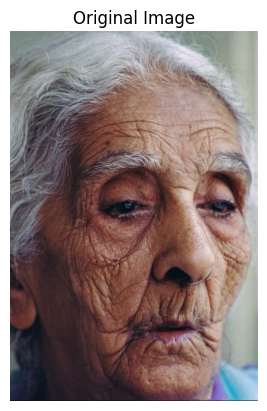

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step

Prediction for the image:
Predicted Age: 101.44
Predicted Gender: Female (1.00)


In [32]:
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array

# Path to the selected image file
image_path = '/content/old age women.jpg'

# Load the image
img = cv2.imread(image_path)

# Check if image was loaded successfully
if img is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Display the original image
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')
    plt.show()

    # Preprocess the image for the model
    # Resize to the target size (200, 200) expected by the model
    img_resized = cv2.resize(img_rgb, (200, 200))

    # Convert to array and normalize (rescale by 1./255 as done in ImageDataGenerator)
    img_array = img_to_array(img_resized)
    img_array = img_array / 255.0  # Normalize

    # Expand dimensions to match model input shape (add batch dimension)
    img_input = np.expand_dims(img_array, axis=0)

    # Make prediction
    predictions = model.predict(img_input)
    predicted_age = predictions[0][0][0]
    predicted_gender_prob = predictions[1][0][0]

    # Convert gender probability to a class (0 for male, 1 for female assuming 0 is male and 1 is female based on common datasets)
    # Or, if 0 is female and 1 is male, adjust this line.
    # Let's assume 0 is male, 1 is female for now as a common practice.
    predicted_gender = 'Female' if predicted_gender_prob > 0.5 else 'Male'

    print(f"\nPrediction for the image:")
    print(f"Predicted Age: {predicted_age:.2f}")
    print(f"Predicted Gender: {predicted_gender} ({predicted_gender_prob:.2f})")


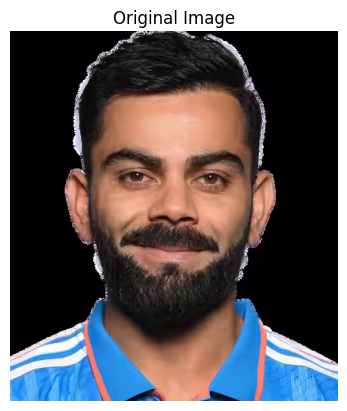

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

Prediction for the image:
Predicted Age: 26.69
Predicted Gender: Male (0.00)


In [34]:
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array

# Path to the selected image file
image_path = '/content/virat.avif'

# Load the image
img = cv2.imread(image_path)

# Check if image was loaded successfully
if img is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Display the original image
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')
    plt.show()

    # Preprocess the image for the model
    # Resize to the target size (200, 200) expected by the model
    img_resized = cv2.resize(img_rgb, (200, 200))

    # Convert to array and normalize (rescale by 1./255 as done in ImageDataGenerator)
    img_array = img_to_array(img_resized)
    img_array = img_array / 255.0  # Normalize

    # Expand dimensions to match model input shape (add batch dimension)
    img_input = np.expand_dims(img_array, axis=0)

    # Make prediction
    predictions = model.predict(img_input)
    predicted_age = predictions[0][0][0]
    predicted_gender_prob = predictions[1][0][0]

    # Convert gender probability to a class (0 for male, 1 for female assuming 0 is male and 1 is female based on common datasets)
    # Or, if 0 is female and 1 is male, adjust this line.
    # Let's assume 0 is male, 1 is female for now as a common practice.
    predicted_gender = 'Female' if predicted_gender_prob > 0.5 else 'Male'

    print(f"\nPrediction for the image:")
    print(f"Predicted Age: {predicted_age:.2f}")
    print(f"Predicted Gender: {predicted_gender} ({predicted_gender_prob:.2f})")


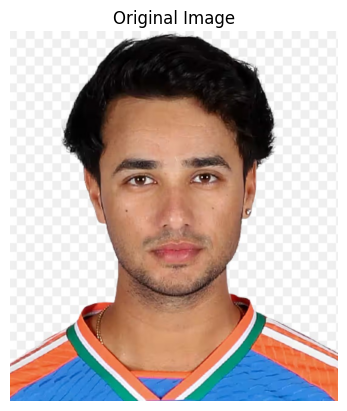

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

Prediction for the image:
Predicted Age: 25.96
Predicted Gender: Male (0.00)


In [36]:
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array

# Path to the selected image file
image_path = '/content/abhishekh.jpeg'

# Load the image
img = cv2.imread(image_path)

# Check if image was loaded successfully
if img is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Display the original image
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')
    plt.show()

    # Preprocess the image for the model
    # Resize to the target size (200, 200) expected by the model
    img_resized = cv2.resize(img_rgb, (200, 200))

    # Convert to array and normalize (rescale by 1./255 as done in ImageDataGenerator)
    img_array = img_to_array(img_resized)
    img_array = img_array / 255.0  # Normalize

    # Expand dimensions to match model input shape (add batch dimension)
    img_input = np.expand_dims(img_array, axis=0)

    # Make prediction
    predictions = model.predict(img_input)
    predicted_age = predictions[0][0][0]
    predicted_gender_prob = predictions[1][0][0]

    # Convert gender probability to a class (0 for male, 1 for female assuming 0 is male and 1 is female based on common datasets)
    # Or, if 0 is female and 1 is male, adjust this line.
    # Let's assume 0 is male, 1 is female for now as a common practice.
    predicted_gender = 'Female' if predicted_gender_prob > 0.5 else 'Male'

    print(f"\nPrediction for the image:")
    print(f"Predicted Age: {predicted_age:.2f}")
    print(f"Predicted Gender: {predicted_gender} ({predicted_gender_prob:.2f})")


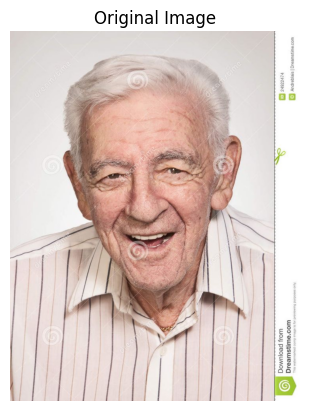

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

Prediction for the image:
Predicted Age: 92.58
Predicted Gender: Male (0.00)


In [43]:
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array

# Path to the selected image file
image_path = '/content/old mann.jpg'

# Load the image
img = cv2.imread(image_path)

# Check if image was loaded successfully
if img is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Display the original image
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')
    plt.show()

    # Preprocess the image for the model
    # Resize to the target size (200, 200) expected by the model
    img_resized = cv2.resize(img_rgb, (200, 200))

    # Convert to array and normalize (rescale by 1./255 as done in ImageDataGenerator)
    img_array = img_to_array(img_resized)
    img_array = img_array / 255.0  # Normalize

    # Expand dimensions to match model input shape (add batch dimension)
    img_input = np.expand_dims(img_array, axis=0)

    # Make prediction
    predictions = model.predict(img_input)
    predicted_age = predictions[0][0][0]
    predicted_gender_prob = predictions[1][0][0]

    # Convert gender probability to a class (0 for male, 1 for female assuming 0 is male and 1 is female based on common datasets)
    # Or, if 0 is female and 1 is male, adjust this line.
    # Let's assume 0 is male, 1 is female for now as a common practice.
    predicted_gender = 'Female' if predicted_gender_prob > 0.5 else 'Male'

    print(f"\nPrediction for the image:")
    print(f"Predicted Age: {predicted_age:.2f}")
    print(f"Predicted Gender: {predicted_gender} ({predicted_gender_prob:.2f})")


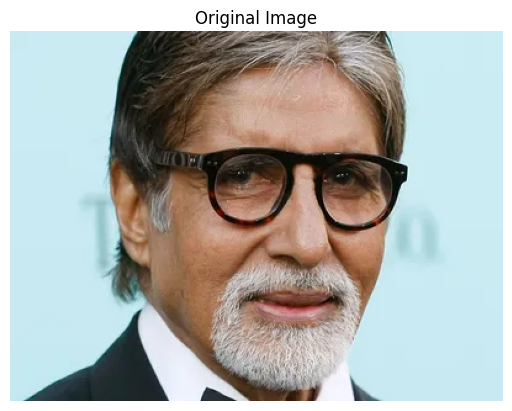

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step

Prediction for the image:
Predicted Age: 79.91
Predicted Gender: Male (0.00)


In [44]:
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array

# Path to the selected image file
image_path = '/content/amitabachan.webp'

# Load the image
img = cv2.imread(image_path)

# Check if image was loaded successfully
if img is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Display the original image
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')
    plt.show()

    # Preprocess the image for the model
    # Resize to the target size (200, 200) expected by the model
    img_resized = cv2.resize(img_rgb, (200, 200))

    # Convert to array and normalize (rescale by 1./255 as done in ImageDataGenerator)
    img_array = img_to_array(img_resized)
    img_array = img_array / 255.0  # Normalize

    # Expand dimensions to match model input shape (add batch dimension)
    img_input = np.expand_dims(img_array, axis=0)

    # Make prediction
    predictions = model.predict(img_input)
    predicted_age = predictions[0][0][0]
    predicted_gender_prob = predictions[1][0][0]

    # Convert gender probability to a class (0 for male, 1 for female assuming 0 is male and 1 is female based on common datasets)
    # Or, if 0 is female and 1 is male, adjust this line.
    # Let's assume 0 is male, 1 is female for now as a common practice.
    predicted_gender = 'Female' if predicted_gender_prob > 0.5 else 'Male'

    print(f"\nPrediction for the image:")
    print(f"Predicted Age: {predicted_age:.2f}")
    print(f"Predicted Gender: {predicted_gender} ({predicted_gender_prob:.2f})")


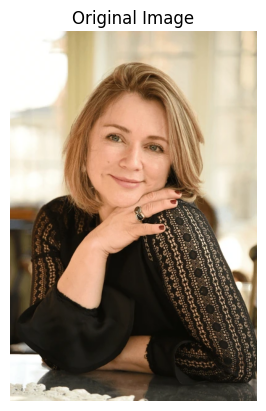

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

Prediction for the image:
Predicted Age: 41.75
Predicted Gender: Female (0.98)


In [46]:
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array

# Path to the selected image file
image_path = '/content/lady.webp'

# Load the image
img = cv2.imread(image_path)

# Check if image was loaded successfully
if img is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Display the original image
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')
    plt.show()

    # Preprocess the image for the model
    # Resize to the target size (200, 200) expected by the model
    img_resized = cv2.resize(img_rgb, (200, 200))

    # Convert to array and normalize (rescale by 1./255 as done in ImageDataGenerator)
    img_array = img_to_array(img_resized)
    img_array = img_array / 255.0  # Normalize

    # Expand dimensions to match model input shape (add batch dimension)
    img_input = np.expand_dims(img_array, axis=0)

    # Make prediction
    predictions = model.predict(img_input)
    predicted_age = predictions[0][0][0]
    predicted_gender_prob = predictions[1][0][0]

    # Convert gender probability to a class (0 for male, 1 for female assuming 0 is male and 1 is female based on common datasets)
    # Or, if 0 is female and 1 is male, adjust this line.
    # Let's assume 0 is male, 1 is female for now as a common practice.
    predicted_gender = 'Female' if predicted_gender_prob > 0.5 else 'Male'

    print(f"\nPrediction for the image:")
    print(f"Predicted Age: {predicted_age:.2f}")
    print(f"Predicted Gender: {predicted_gender} ({predicted_gender_prob:.2f})")


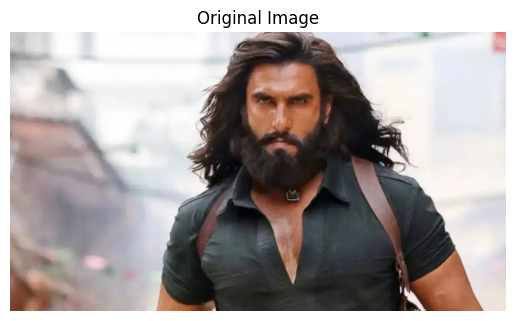

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

Prediction for the image:
Predicted Age: 33.76
Predicted Gender: Female (0.95)


In [42]:
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array

# Path to the selected image file
image_path = '/content/ranveer.webp'

# Load the image
img = cv2.imread(image_path)

# Check if image was loaded successfully
if img is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Display the original image
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')
    plt.show()

    # Preprocess the image for the model
    # Resize to the target size (200, 200) expected by the model
    img_resized = cv2.resize(img_rgb, (200, 200))

    # Convert to array and normalize (rescale by 1./255 as done in ImageDataGenerator)
    img_array = img_to_array(img_resized)
    img_array = img_array / 255.0  # Normalize

    # Expand dimensions to match model input shape (add batch dimension)
    img_input = np.expand_dims(img_array, axis=0)

    # Make prediction
    predictions = model.predict(img_input)
    predicted_age = predictions[0][0][0]
    predicted_gender_prob = predictions[1][0][0]

    # Convert gender probability to a class (0 for male, 1 for female assuming 0 is male and 1 is female based on common datasets)
    # Or, if 0 is female and 1 is male, adjust this line.
    # Let's assume 0 is male, 1 is female for now as a common practice.
    predicted_gender = 'Female' if predicted_gender_prob > 0.5 else 'Male'

    print(f"\nPrediction for the image:")
    print(f"Predicted Age: {predicted_age:.2f}")
    print(f"Predicted Gender: {predicted_gender} ({predicted_gender_prob:.2f})")


In [25]:
import tensorflow as tf

# Define the path to save your model in native Keras (.keras) format
model_save_path_keras = '/content/age_gender_prediction_model.keras'

# Save the model in the native Keras format
model.save(model_save_path_keras)
print(f"Model saved successfully to {model_save_path_keras} in native Keras format.")

Model saved successfully to /content/age_gender_prediction_model.keras in native Keras format.


# Conclusion

Successfully developed a multi-output deep learning model using ResNet50 and CNN techniques to predict:
- Age
- Gender

from facial images using transfer learning, fine-tuning, and data augmentation.